## RFM CUSTOMER SEGMENTATION ANALYSIS

## Business Problem

Olist marketplace is experiencing a severe customer retention crisis with 97% of customers making only one purchase. This represents a significant revenue leakage and indicates that the platform is failing to convert first-time buyers into loyal customers.

The business needs to:
1. Identify which customer segments exist in the current base
2. Understand the characteristics of high-value vs low-value customers
3. Develop targeted retention strategies for each segment
4. Prioritize marketing spend on segments with highest ROI potential

## Analysis Objective

Use RFM (Recency, Frequency, Monetary) methodology to segment customers based on purchasing behavior and recommend actionable marketing strategies per segment.

## Expected Outcomes
- Clear customer segments with defined characteristics
- Revenue contribution analysis per segment
- Targeted action plans for retention campaigns
- Identification of high-priority segments for immediate intervention

In [ ]:
!pip install sqlalchemy pymysql

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from urllib.parse import quote_plus


In [ ]:

pd.set_option('display.max_columns', None)

In [ ]:
import os
from dotenv import load_dotenv
from urllib.parse import quote_plus

In [ ]:
load_dotenv()

username = os.getenv("DB_USERNAME")
password = quote_plus(os.getenv("DB_PASSWORD"))
host = os.getenv("DB_HOST")
database = os.getenv("DB_DATABASE")

In [ ]:
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:3306/{database}",
    pool_pre_ping=True
)

In [ ]:
# test connection
test_df = pd.read_sql("SELECT 1", engine)
test_df

,1
0,1


In [ ]:
query = """
SELECT
    customer_unique_id,
    order_id,
    order_purchase_timestamp,
    order_revenue
FROM fact_orders
WHERE order_status = 'DELIVERED'
"""


In [ ]:
df = pd.read_sql(query, engine)

In [ ]:

print(df.shape)
df.head()

(96478, 4)


,customer_unique_id,order_id,order_purchase_timestamp,order_revenue
0,871766c5855e863f6eccc05f988b23cb,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13 08:59:02,58.90
1,eb28e67c4c0b83846050ddfb8a35d051,00018f77f2f0320c557190d7a144bdd3,2017-04-26 10:53:06,239.90
2,3818d81c6709e39d06b2738a8d3a2474,000229ec398224ef6ca0657da4fc703e,2018-01-14 14:33:31,199.00
3,af861d436cfc08b2c2ddefd0ba074622,00024acbcdf0a6daa1e931b038114c75,2018-08-08 10:00:35,12.99
4,64b576fb70d441e8f1b2d7d446e483c5,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04 13:57:51,199.90


## Data Preprocessing

Convert purchase timestamp to datetime format for RFM calculations

Drop any rows with invalid timestamps (rare but production-safe)



In [ ]:

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

In [ ]:
print("Null timestamps BEFORE drop:",
      df["order_purchase_timestamp"].isna().sum())

print("Shape BEFORE drop:", df.shape)

Null timestamps BEFORE drop: 0
Shape BEFORE drop: (96478, 4)


In [ ]:
# Drop any bad rows (rare but production-safe)
df = df.dropna(subset=["order_purchase_timestamp"])

In [ ]:
print("Shape AFTER drop:", df.shape)

Shape AFTER drop: (96478, 4)


In [ ]:
df['customer_unique_id'].isna().sum()

np.int64(0)

Note: No null timestamps found in this dataset, but handling is defensive programming practice

**Calculate RFM Metrics**

RECENCY: Days since last purchase (lower = better = more recent engagement)

- Calculated as: (snapshot_date - max(purchase_date)) 
- Snapshot date = day after last order in dataset

  
FREQUENCY: Total number of unique orders per customer
- Uses nunique() to count distinct order_ids
- Most customers = 1 order (one-time buyers)
   
MONETARY: Total revenue generated by customer
- Sum of order_revenue across all purchases
- Represents customer lifetime value

This aggregation creates one row per customer_unique_id

In [ ]:

snapshot_date = df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("customer_unique_id", as_index=False)
      .agg(
          recency=("order_purchase_timestamp",
                   lambda x: (snapshot_date - x.max()).days),
          frequency=("order_id", "nunique"),
          monetary=("order_revenue", "sum"),
      )
      .rename(columns={"customer_unique_id": "customer_id"})
)


In [ ]:
print("Customers in df:", df['customer_unique_id'].nunique())
print("Customers in rfm:", rfm['customer_id'].nunique())

missing = set(df['customer_unique_id']) - set(rfm['customer_id'])
print("Customers lost during RFM:", len(missing))

Customers in df: 93358
Customers in rfm: 93358
Customers lost during RFM: 0


In [ ]:
# how many unique customer-order pairs truly exist
print(
    df[['customer_unique_id','order_id']]
    .drop_duplicates()['customer_unique_id']
    .nunique()
)

93358


## RFM Scoring (1-5 Scale Using Quintiles)

 Each metric is divided into 5 equal bins (quintiles) and scored:

R_SCORE (Recency): 5 = most recent, 1 = least recent
- Lower recency days = higher score (inverted scale)
- quintile approach ensures equal distribution

F_SCORE (Frequency): 5 = most orders, 1 = fewest orders
- rank(method='first') handles ties (many customers have frequency=1)
- Ensures scores are evenly distributed despite skewed frequency

M_SCORE (Monetary): 5 = highest spend, 1 = lowest spend
- Standard quintile split on total revenue

duplicates='drop' handles cases where not all 5 bins are possible due to data distribution

In [ ]:

rfm["R_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)


## Customer Segmentation Logic

Segments are defined using behavioral rules derived from RFM scores and actual purchase frequency:

TOP CUSTOMERS: R >= 4 AND F >= 4 AND M >= 4

High value across recency, frequency, and monetary dimensions.

LOYAL CUSTOMERS: frequency >= 2 AND M >= 3

Customers with repeat purchases and strong spending.

RECENT BUYERS: R >= 4 AND frequency = 1

New or recently active one-time buyers with high conversion potential.

FREQUENT BUYERS: frequency >= 2 (but not qualifying as Loyal Customers)

Repeat purchasers with relatively lower spend.

AT RISK: All remaining customers

Primarily one-time buyers with low recency or engagement.


In [ ]:

rfm["RFM_score"] = (
    rfm["R_score"].astype(int)
    + rfm["F_score"].astype(int)
    + rfm["M_score"].astype(int)
)

In [ ]:
def segment_customer(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])
    freq_raw = row["frequency"]   

    # Top Customers
    if r >= 4 and f >= 4 and m >= 4:
        return "Top Customers"

    # Loyal Customers
    elif freq_raw >= 2 and m >= 3:
        return "Loyal Customers"

    # Recent Buyers
    elif r >= 4 and freq_raw == 1:
        return "Recent Buyers"

    # TRUE Frequent Buyers (REAL repeat behavior)
    elif freq_raw >= 2:
        return "Frequent Buyers"

    else:
        return "At Risk"


In [ ]:
rfm["segment"] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm["segment"].value_counts()

segment
At Risk            54333
Recent Buyers      30712
Top Customers       6449
Loyal Customers     1587
Frequent Buyers      277
Name: count, dtype: int64

In [ ]:
# 8. SEGMENT SUMMARY (BUSINESS VIEW)
# =========================
segment_summary = (
    rfm.groupby("segment", as_index=False)
       .agg(
           customers=("customer_id", "count"),
           avg_monetary=("monetary", "mean"),
           avg_frequency=("frequency", "mean"),
       )
       .sort_values("avg_monetary", ascending=False)
)

print(segment_summary)

           segment  customers  avg_monetary  avg_frequency
4    Top Customers       6449    275.762897       1.172895
2  Loyal Customers       1587    257.070403       2.080025
0          At Risk      54333    136.383488       1.000000
3    Recent Buyers      30712    117.577891       1.000000
1  Frequent Buyers        277     50.383430       2.050542


C:\Users\nethra\AppData\Local\Temp\ipykernel_22668\2721989878.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


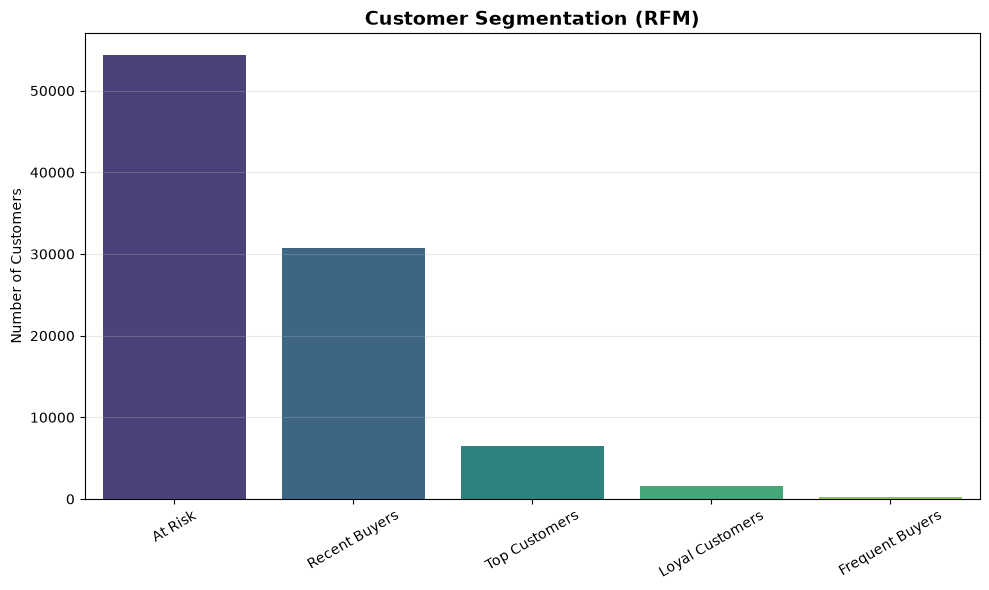

In [ ]:
# 9. VISUALIZATION
# =========================
plt.figure(figsize=(10,6))

order = (
    rfm['segment']
    .value_counts()
    .sort_values(ascending=False)
    .index
)

sns.countplot(
    data=rfm,
    x='segment',
    order=order,
    palette='viridis'
)

plt.title('Customer Segmentation (RFM)', fontsize=14, weight='bold')
plt.xlabel('')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
rev_summary = (
    rfm.groupby('segment')['monetary']
    .sum()
    .sort_values(ascending=False)
)

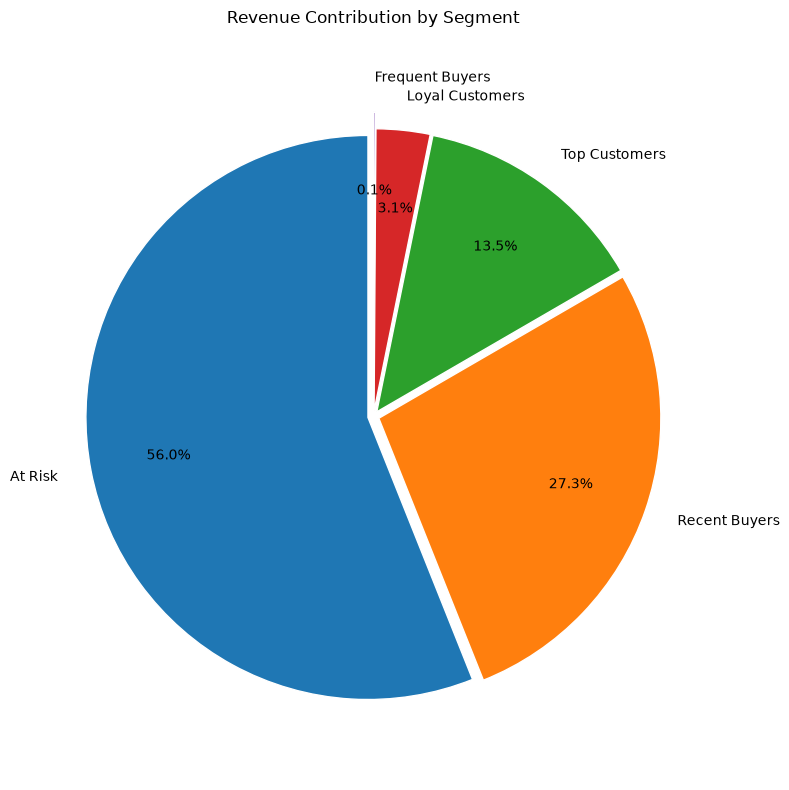

In [ ]:
plt.figure(figsize=(8,8))

explode = [0.08 if v < (rev_summary.sum()*0.01) else 0.02 
           for v in rev_summary.values]

rev_summary.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    pctdistance=0.72,
    labeldistance=1.12,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.title('Revenue Contribution by Segment')
plt.ylabel('')
plt.axis('equal')  # keeps circle perfect
plt.tight_layout()
plt.show()

In [ ]:
rfm["buyer_type"] = np.where(
    rfm["frequency"] == 1,
    "One-time Buyer",
    "Repeat Buyer"
)

rfm["buyer_type"].value_counts()

buyer_type
One-time Buyer    90557
Repeat Buyer       2801
Name: count, dtype: int64

In [ ]:
segment_vs_repeat = pd.crosstab(
    rfm["segment"],
    rfm["buyer_type"],
    normalize="index"
) * 100

segment_vs_repeat.round(2)

buyer_type,One-time Buyer,Repeat Buyer
segment,,
At Risk,100.00,0.00
Frequent Buyers,0.00,100.00
Loyal Customers,0.00,100.00
Recent Buyers,100.00,0.00
Top Customers,85.47,14.53


In [ ]:
#pushing the table back into gold layer for power bi analysis later
rfm.to_sql("rfm", engine, if_exists="replace", index=False)

93358

## Key Findings

### 1. RETENTION CRISIS CONFIRMED
- **97.0%** of customers are one-time buyers (90,557 of 93,358)
- Only **3.0%** show repeat purchase behaviour (2,801 customers)
- The customer base is heavily skewed toward single-purchase users, indicating a strong retention opportunity.

### 2. SEGMENT DISTRIBUTION

Segment distribution based on RFM segmentation:

At Risk: 54,333 customers (58.2%)

Recent Buyers: 30,712 customers (32.9%)

Top Customers: 6,449 customers (6.9%)

Loyal Customers: 1,587 customers (1.7%)

Frequent Buyers: 277 customers (0.3%)

Key Insight:
The customer base is dominated by low-engagement users, with a very small core of high-value repeat customers.

### 3. Business Interpretation
- The analysis reveals that the marketplace is heavily dependent on one-time purchasers. 
- With 58% of customers classified as At Risk and only ~2% in high-loyalty segments (Loyal + Frequent Buyers), the business has significant untapped lifetime value.
- This indicates the primary growth lever is improving second-purchase conversion, rather than only focusing on new customer acquisition.
- If even 10% of Recent Buyers are successfully converted into repeat purchasers, the platform can unlock substantial incremental revenue without increasing acquisition spend.

### 4. BUSINESS IMPACT
If Recent Buyers segment (30,712 customers) can be converted into repeat purchasers:

`Potential revenue opportunity:
30,712 customers × R$150 avg second order ≈ R$4.61M`

`Conservative scenario (10% conversion):
~3,071 customers × R$150 ≈ R$460K incremental revenue`

### 5. Methodological Note & Limitations
- **RFM is only partially applicable to this dataset.** Because ~97% of customers placed exactly one order, the **Frequency** dimension is near-constant (frequency = 1 for almost everyone). The F-score is assigned by `rank(method='first')` tie-breaking *among* one-time buyers, so for the bulk of the base it carries little genuine signal.
- In practice the segmentation is driven mainly by **Recency** and **Monetary**; Frequency only separates the ~3% repeat tail. The explicit `frequency >= 2` rules in the segment logic (Loyal / Frequent Buyers) — not the F quintiles — are what actually isolate real repeat behaviour.
- On a static historical extract, **Recency** also reduces to "how long ago the single order was placed" against a fixed snapshot date, rather than live engagement.
- **Takeaway:** read these segments as a Recency/Monetary value map with a small repeat-buyer overlay. A base this dominated by one-time buyers is arguably better served by an explicit *first → second purchase conversion model*; RFM is applied here to demonstrate the technique and frame the retention opportunity, not because frequency is richly distributed.

## Recommended Actions

### IMMEDIATE (Week 1-2):
1. Launch targeted second-purchase coupon for Recent Buyers
   - Trigger: 24 to 48 hours after first purchase
   - Validity: 30 days
   - Expected impact: Improve second-purchase conversion
   
2. Light re-engagement campaign for At Risk customers
   - Personalized reminder emails
   - Product recommendations based on first purchase
   - Goal: prevent complete churn rather than deep discounting

### SHORT-TERM (Month 1-2):
3. Strengthen retention of Top Customers
   - Early access to sales
   - Free or expedited shipping
   - Priority customer support
   - Objective: protect high-LTV users who already drive disproportionate revenue.

4. Nurture Loyal Customers toward Top Customer tier
   - Bundle offers
   - Cross-category recommendations
   - Spend-based rewards

### LONG-TERM (Quarter 1-2):
5. Build structured loyalty program for repeat buyers
   - Points-based rewards
   - Referral incentives
   - Tier progression system

6. Category-level repeat analysis
   - Identify categories with highest repeat probability
   - Prioritize retention spend in high-repeat categories
   - Optimize merchandising accordingly
     
### SUCCESS METRICS TO TRACK:
  - Repeat purchase rate (target: improve from ~3.0% to ~8% in 6 months)
  - Recent Buyers second-purchase conversion (target: 5 to 8%)
  - Top Customer retention rate (target: maintain above 90%)
  - Average orders per customer (target: gradual lift through repeat behavior)